# Data Science Project - Progress Report #2
## Data Exploration
Serena Reese
<br>
Dr. Erdogan Dogdu
<br>
October 29, 2025

In [1]:
# Import packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/CS/AI Cybersecurity/CIS_datasets/AggregateDataSet/scada_resolved_agg_10s.csv")

#Step 1 -- Identify numerical and categorical features in the dataset, and list them out with their ranges and category values

## Preprocess the data

### Displays first few rows

In [3]:
print(df.head())

                      bucket         system_id protocol  avg_size  \
0  2021-04-09 11:30:50+00:00  testbed_system_1      TCP      60.0   
1  2021-04-09 11:30:50+00:00  testbed_system_1   Modbus      65.0   
2  2021-04-09 11:30:50+00:00  testbed_system_1      TCP      60.0   
3  2021-04-09 11:30:50+00:00  testbed_system_1   Modbus      65.0   
4  2021-04-09 11:30:50+00:00  testbed_system_1      TCP      60.0   

   source_total_packets  destination_total_packets  min_size  max_size  \
0                    18                        302        60        60   
1                     7                         16        65        65   
2                    44                        104        60        60   
3                     7                         16        65        65   
4                    44                        104        60        60   

   num_connections    source_ip  ...         source_mac destination_ip  \
0                6  84.3.251.18  ...  00:80:f4:03:fb:12    84.3.25

**Interpretation:**
<br>
<br>
This network traffic metadata comes from a single testbed system used for anomaly detection and cybersecurity analysis. It includes a timeframe, system, protocols and assets.
<br>
<br>
All timeframe entries are from the same timestamp -- April 9, 2021 at 11:30:50 UTC. All traffic originates from testbed_system_1. There are two observed protocols -- TCP and Modbus. Assets show that communication occurs between PLCs and an HMI. Rows 2, 4 and 5 appear to be duplicates of each other. Rows 1 and 3 seem identical as well, yet row 0 is unique.

**Columns:**
<br>
<br>
**Timestamp and System**

| Column    | Description |
| :------   | :-: |
| bucket    | timestamp of traffic snapshot |
| system_id | identifies traffic-generating system |

<br>

**Protocol and Packet Metrics**

| Column            | Description |
| :------           | :-: |
| protocol          | TCP or Modbus |
| avg_size          | average packet size |
| min_size/max_size | packet size range |
| source_total_packets/destination_total_packets | counts of received/sent packets |

<br>

**Connection Details**
| Column                     | Description |
| :------                    | :-: |
| num_connections            | number of distinct, observed connections |
| source_ip/destination_ip   | IP addresses |
| source_mac/destination_mac | device MAC addresses |
| destination_port           | destination device's port |

<br>

**Logical Keys and Assets**
| Column                         | Description |
| :------                        | :-: |
| source_key/destination_key     | IP logical identifiers |
| source_asset/destination_asset | device roles |

<br>

**Security Indicators**
| Column        | Description |
| :------       | :-: |
| num_attacks   | all entries show 0 attacks |
| attack_types  | all labeled "normal" |


### Provides basic info about the data types and missing values

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366173 entries, 0 to 366172
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   bucket                     366173 non-null  object 
 1   system_id                  366173 non-null  object 
 2   protocol                   366173 non-null  object 
 3   avg_size                   366173 non-null  float64
 4   source_total_packets       366173 non-null  int64  
 5   destination_total_packets  366173 non-null  int64  
 6   min_size                   366173 non-null  int64  
 7   max_size                   366173 non-null  int64  
 8   num_connections            366173 non-null  int64  
 9   source_ip                  365718 non-null  object 
 10  source_port                365619 non-null  float64
 11  source_mac                 366173 non-null  object 
 12  destination_ip             365718 non-null  object 
 13  destination_port           36

**Interpretation:**
<br>
<br>
There are 366,173 rows, each indicating a unique communication event/aggregated flow. There are 21 total columns detailing timestamps, protocol details, packet metrics, connection metadata and attack annotations. The memory footprint is about 58.7 MB, which is manageable for in-memory analysis, but probably should be batched for modeling.
<br>
<br>
There are 12 object types that are categorical/string-based fields. There are only 3 float64 types that show continuous metrics, and an additional 6 int64 types showing discrete counts.
<br>
<br>
The temporal and system context includes only a bucket and system_id, while traffic metrics include:
1. Packet caracteristics -- protocol, avg_size, min_size and max_size
2. Volume metrics -- source_total_packets and destination_total_packets
3. Connection count per flow -- num_connections

<br>

Network identifiers include:
1. Device-level identifiers -- source_ip, destination_ip, source_mac and destination_mac
2. Communication endpoints -- source_port and destination_port
3. Hashed/Normalized identifiers -- source_key and destination_key

<br>

There are additionally two security labels -- num_attacks and attack_types, along with two asset mapping fields -- source_asset and destination_asset. There may be incomplete packet captures, non-ip protocols, internal routing or broadcast traffic, because some fields have missing entries:
1. source_ip, destination_ip -- about 455 missing
2. source_port, destination_port -- about 554 missing
3. source_asset, destination_asset -- about 475 missing

### Shows basic statistics for numerical columns

In [5]:
df.describe(include="all")

,bucket,system_id,protocol,avg_size,source_total_packets,destination_total_packets,min_size,max_size,num_connections,source_ip,...,source_mac,destination_ip,destination_port,destination_mac,source_key,destination_key,num_attacks,attack_types,source_asset,destination_asset
count,366173,366173,366173,366173.000000,3.661730e+05,3.661730e+05,366173.000000,366173.000000,366173.000000,365718,...,366173,365718,365619.000000,366173,366173,366173,366173.000000,366173,365676,365698
unique,1095,1,5,NaN,NaN,NaN,NaN,NaN,NaN,8,...,9,8,NaN,10,17,17,NaN,11,7,7
top,2022-02-21 15:12:20+00:00,testbed_system_1,TCP,NaN,NaN,NaN,NaN,NaN,NaN,84.3.251.20,...,00:0c:29:47:8c:0e,84.3.251.18,NaN,00:80:f4:03:fb:12,84.3.251.20,84.3.251.18,NaN,['normal'],testbed_system_1_HMI_HMI_1,testbed_system_1_PLC_PLC_1
freq,62178,366173,281082,NaN,NaN,NaN,NaN,NaN,NaN,138849,...,134801,201679,NaN,201432,138849,201679,NaN,166656,138849,201679
mean,NaN,NaN,NaN,64.715387,2.603490e+03,3.157119e+03,63.596560,66.518747,79.415836,NaN,...,NaN,NaN,13564.448680,NaN,NaN,NaN,23.561715,NaN,NaN,NaN
std,NaN,NaN,NaN,13.033572,1.966281e+05,2.006727e+05,12.343457,13.976035,2125.741578,NaN,...,NaN,NaN,21407.290001,NaN,NaN,NaN,2086.704454,NaN,NaN,NaN
min,NaN,NaN,NaN,60.000000,0.000000e+00,0.000000e+00,60.000000,60.000000,1.000000,NaN,...,NaN,NaN,25.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,60.000000,0.000000e+00,1.700000e+01,60.000000,60.000000,1.000000,NaN,...,NaN,NaN,502.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,60.000000,7.000000e+00,7.200000e+01,60.000000,60.000000,2.000000,NaN,...,NaN,NaN,502.000000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,68.666667,4.400000e+01,1.100000e+02,66.000000,74.000000,5.000000,NaN,...,NaN,NaN,35553.000000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN


**Interpretation:**
<br>
<br>
There are 366,173 entries for rows, along with slightly fewer non-null entries (approx. 365,619) for port fields due to missing values. Packet sizes are highly consistent at lower percentiles, but there are some extreme outliers at the upper end. Attack counts are mostly zero or one, but there are a few massive spikes with highest at 620,183.
<br>
<br>
*Packet Size Metrics*
<br>
Most packets are small and uniform at 60 bytes, so they're either protocol headers or control messages. The 1514-byte max suggests that there are occasional full payloads/jumbo frames. Tight clustering at 60 bytes could be used for protocol fingerprinting and baseline modeling.
<br>
<br>
*Packet Volume*
<br>
Median values are low, ranging from 7 to 72. Extreme outliers dominate the mean, however. The distribution is heavily-tailed, so it's ideal for log transformation/binning. There's likely a mixture of both idle assets and high-thoroughput nodes.
<br>
<br>
*Connection Metrics*
<br>
Most flows involve a few connections, but other assets are instead hyper-connected, which is good for anomaly scoring/clustering.
<br>
<br>
*Port Usage*
<br>
There's a wide spread across ephemeral and well-known ports. The median destination port at 502 is used for industrial control (Modbus traffic), which could be further analyzed and used for protocol inference and service mapping.
<br>
<br>
*Attack Metrics*
<br>
Most entries are benign with a median of 1 or less, but a few records dominate the attack volume. These are likely DoS/scanning bursts, so we could consnider stratified sampling or anomaly weighting.

### Identifies numerical and categorical features

In [6]:
# Selects numerical columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

#Selects categorical columns
categorical_features = df.select_dtypes(include=['object', 'category']).columns

print("Numerical Features:")
print(numerical_features)

print("\n")

print("Categorical Features:")
print(categorical_features)

Numerical Features:
Index(['avg_size', 'source_total_packets', 'destination_total_packets',
       'min_size', 'max_size', 'num_connections', 'source_port',
       'destination_port', 'num_attacks'],
      dtype='object')


Categorical Features:
Index(['bucket', 'system_id', 'protocol', 'source_ip', 'source_mac',
       'destination_ip', 'destination_mac', 'source_key', 'destination_key',
       'attack_types', 'source_asset', 'destination_asset'],
      dtype='object')


**Interpretation:**
<br>
<br>
Numerical features suitable for statistical analysis, scaling, binnning and anomaly scoring include:
1. avg_size
2. source_total_packets
3. destination_total_packets
4. min_size
5. max_size
6. num_connections
7. source_port
8. destination_port
9. num_attacks

<br>

For modeling, we should use log scaling, quantile binning and correlation pruning, because we have heavy-tailed distributions.

<br>

Categorical features for encoding, grouping and stratified analysis include:
1. bucket
2. system_id
3. protocol
4. source_ip
5. destination_ip
6. source_mac
7. destination_mac
8. source_key
9. destination_key
10. attack_types
11. source_asset
12. destination_asset

<br>

High-cardinality fields like IP and MAC should probably be frequency or target encoded, and grouping by asset roles and protocol could reveal behavioral clusters.

### List the ranges (for numerical features) and unique values (for categorical features)

In [7]:
print("Numerical features:")
for col in numerical_features:
    print(f"{col} → range: {df[col].min()} to {df[col].max()}")

print("\nCategorical features:")
for col in categorical_features:
    print(f"{col} → categories: {df[col].unique()}")

Numerical features:
avg_size → range: 60.0 to 1514.0
source_total_packets → range: 0 to 60048180
destination_total_packets → range: 0 to 60051451
min_size → range: 60 to 1514
max_size → range: 60 to 1514
num_connections → range: 1 to 620183
source_port → range: 0.0 to 65535.0
destination_port → range: 25.0 to 61646.0
num_attacks → range: 0 to 620183

Categorical features:
bucket → categories: ['2021-04-09 11:30:50+00:00' '2021-04-09 11:31:00+00:00'
 '2021-04-09 11:31:10+00:00' ... '2022-02-21 15:13:30+00:00'
 '2022-02-21 15:13:40+00:00' '2022-02-21 15:13:50+00:00']
system_id → categories: ['testbed_system_1']
protocol → categories: ['TCP' 'Modbus' 'ARP' 'ICMP' 'IP']
source_ip → categories: ['84.3.251.18' '84.3.251.20' '84.3.251.101' '84.3.251.102' '84.3.251.103'
 '84.3.251.104' '84.3.251.105' nan '84.3.251.110']
source_mac → categories: ['00:80:f4:03:fb:12' '74:46:a0:bd:a7:1b' 'e6:3f:ac:c9:a8:8c'
 '0a:fe:ec:47:74:fb' 'fa:00:bc:90:d7:fa' '4a:35:83:e0:3d:a4'
 'fe:bb:16:7b:c3:27' '00:0c:2

**Interpretation:**
<br>
<br>

*Numerical Features*
| Feature | Range | Description |
| :----------- | :------------: | ------------: |
| avg_size       | 60.0 - 1514.0         | most values cluster at 60        |
| source_total_packets/destination_total_packets   | 0 - approx. 60 million  | heavy-tailed     |
| min_size/max_size    | 60 - 1514  | often identical     |
| num_connections    | 1 - 620,183  | strong signal for asset centrality     |
| source_port/destination_port    | 0 - 65535/ 25 - 61646  | covers full port spectrum, but 502 likely Modbus     |
| num_attacks    | 0 - 620,183  | sparse, but extreme     |

<br>

*Categorical Features*
| Feature | Cardinality | Description |
| :----------- | :------------: | ------------: |
| bucket       | high         | timestamp buckets        |
| system_id    | 1  | single system     |
| protocol    | 5  | TCP, Modbus, ARP, ICMP and IP     |
| source_ip/destination_ip    | about 9 + NaNs  | small IP space     |
| source_mac/destination_mac    | about 9 - 10  | device-level identifiers     |
| source_key/destination_key    | about 17  | logical identifiers     |
| attack_types    | 11  | rich label space     |
| source_asset/destination_asset    | about 7 + NaNs  | PLCs, HMIs and sensors     |

Statistically tests skewness within the dataset

In [8]:
from scipy.stats import skew

feature = 'num_connections'   # numeric feature

skew_value = skew(df[feature].dropna())
print(f"Skewness of feature {feature}: {skew_value}")

if(skew_value > 0):
  print("Right-skewed distribution identified.")
elif(skew_value < 0):
  print("Left-skewed distribution identified.")
else:
  print("Likely a symmetric distribution.")

Skewness of feature num_connections: 241.66662191334086
Right-skewed distribution identified.


**Interpretation:**
<br>
<br>
Nearly all numeric features in the dataset are highly right-skewed.

# Step 2 -- Show an example of each of the following single feature plots on your dataset, and and explain the results of each plot briefly

## Seaborn single feature plots

### Creates a histogram of the named numerical feature from the dataframe

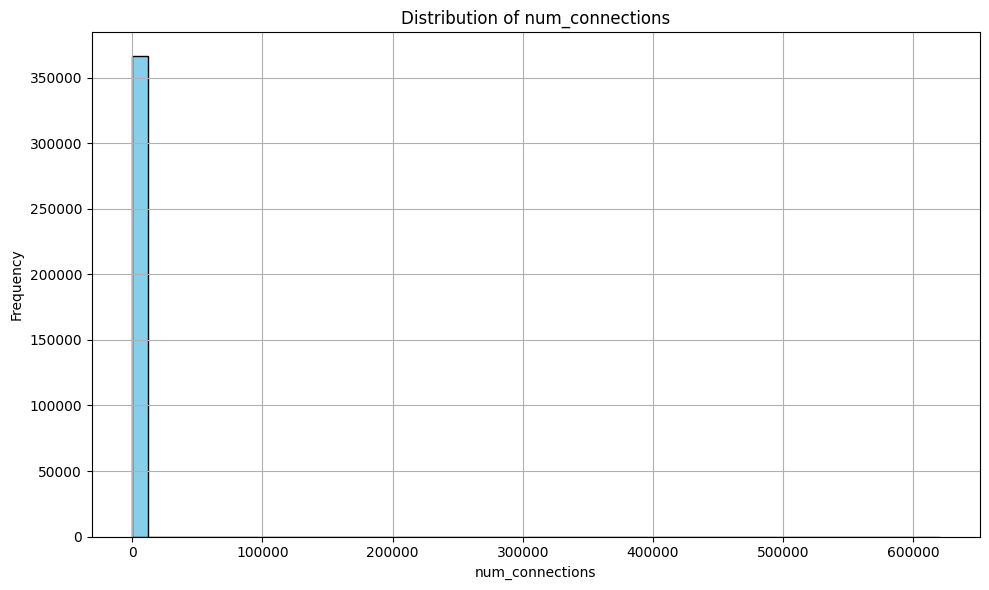

In [9]:
# Shows the distribution of values for one numeric variable
feature = 'num_connections'  # numerical col to plot

plt.figure(figsize=(10, 6))
plt.hist(df[feature].dropna(), bins=50, color='skyblue', edgecolor='black')
plt.title(f'Distribution of {feature}')
plt.xlabel(feature)
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation:**
<br>
<br>
The distribution of each numerical feature is highly-skewed. Over 350,000 entries have few connections. Outliers are rare and extreme. Most flows are thus sparse, and devices communicate predictably. Log scaling or binning would reveal more nuance.

### Creates a density plot of the named numerical feature from the dataframe

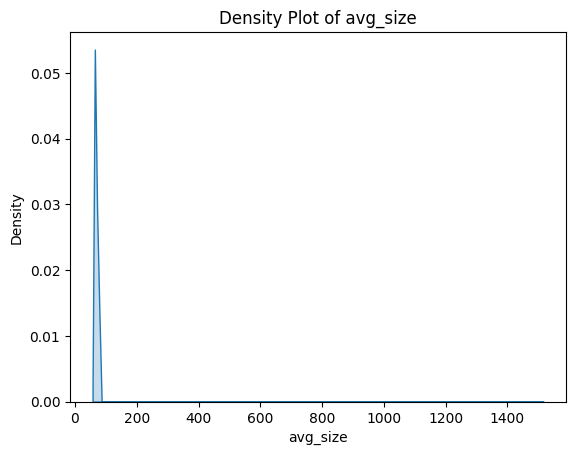

In [10]:
# Smooth curve version of histogram for skewness and modality
feature = 'avg_size'  # col to visualize

sns.kdeplot(df, x=feature, fill=True)
plt.title(f'Density Plot of {feature}')
plt.show()

**Interpretation:**
<br>
<br>
There's a dominant concentration of small packet sizes. As size increases, there's also a steep drop-off. Most packets are minimal with occasional full payloads or protocol-specific bursts, so there's strong modal behavior.

### Creates a bar chart of the named categorical feature from the dataframe

<Axes: xlabel='attack_types', ylabel='count'>

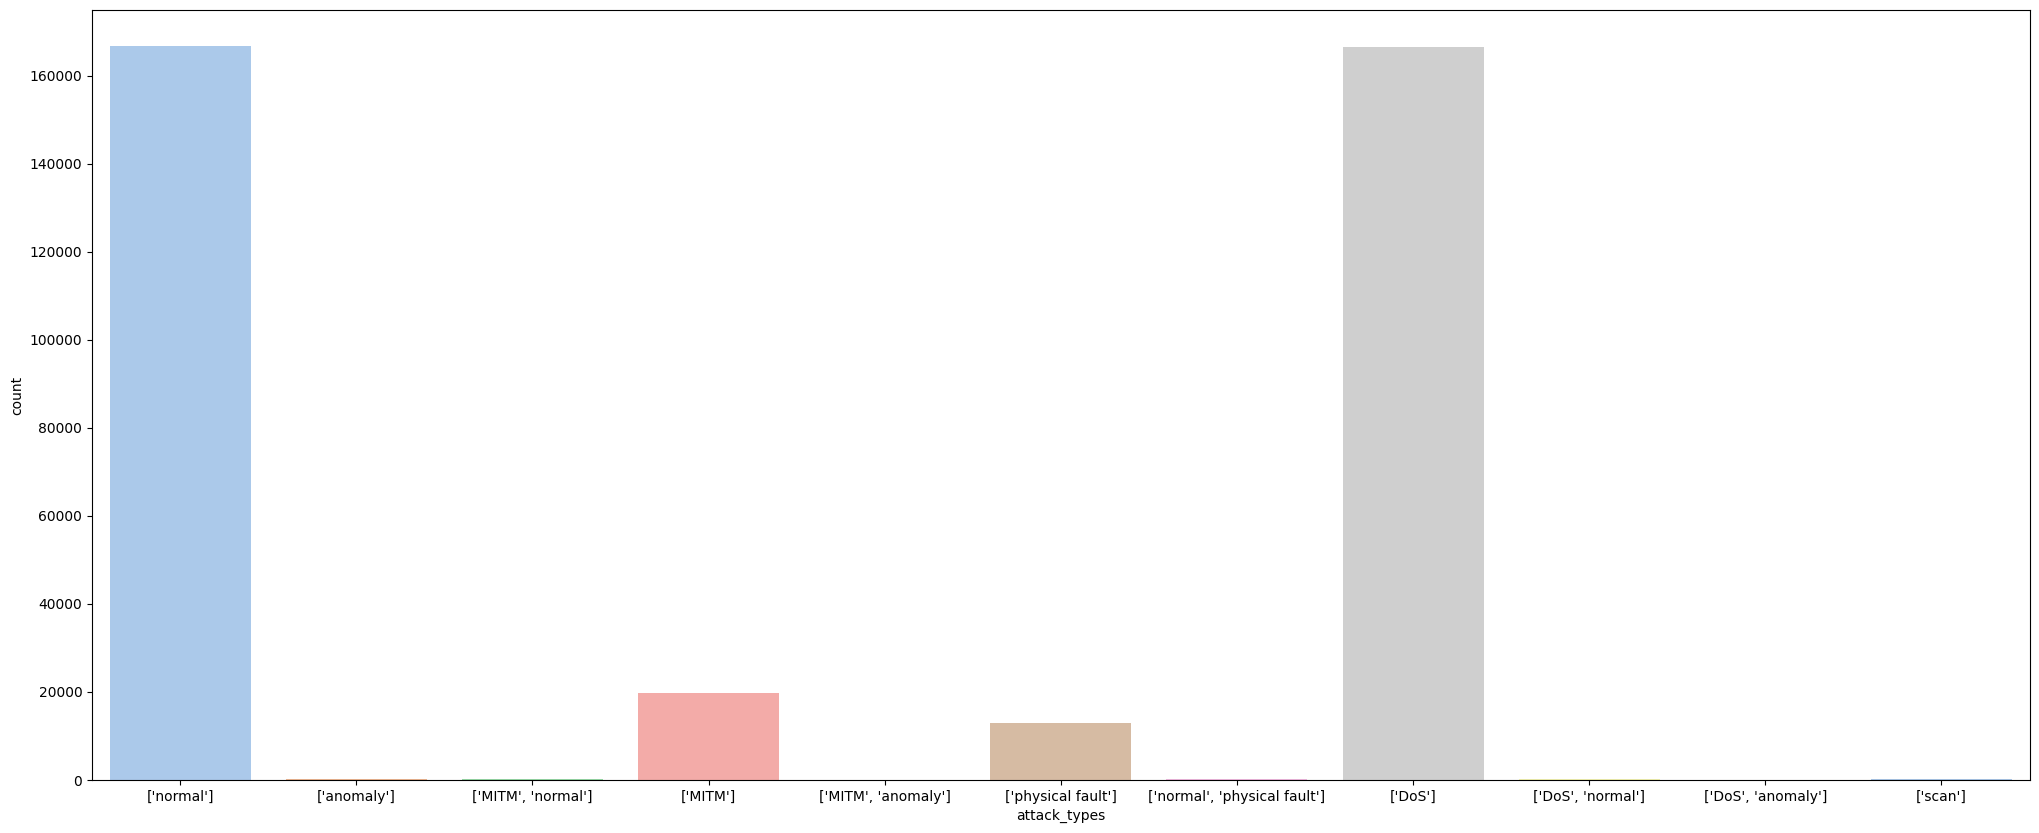

In [11]:
feature = 'attack_types'   # col

plt.figure(figsize=(25, 10))
sns.countplot(df, x=feature, hue=feature, palette='pastel', legend=False)

**Interpretation:**
<br>
<br>
There's a strong class imbalance with 'normal' and 'DoS' as the most frequent types. There are also multi-label entries with labels like 'INTENT', 'anomaly' and 'physical fault' as most rare. We likely need to oversample or weigh by class. To do this, we could use SMOTE, stratified sampling or anomaly-focused metrics like precision-recall. We could reduce fragmentation by normalizing variants like 'Dos' and 'DoS, possibly also ['DoS', 'normal'].

### Creates a box plot of the named numerical feature from the dataframe

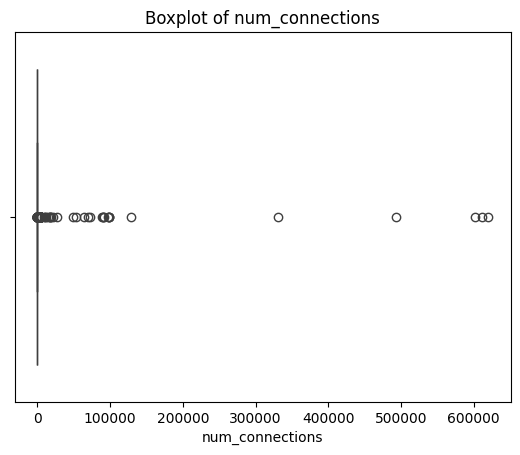

In [12]:
feature = 'num_connections' # col

sns.boxplot(df, x=feature)
plt.title(f'Boxplot of {feature}')
plt.show()

**Interpretation:**
<br>
<br>
This clearly shows the extreme skew, because the IQR is tightly packed with most flows involving few connections. There are numerous extreme outliers, indicating rare yet massive connection bursts, which could be scans, central hubs or attack behavior. The distribution is long-tailed, so we could flag flows above the 95th percentile as potential anomalies/central assets. We could additionally combine this with source_asset or protocol to see which roles exhibit high connectivity, and to make our model more interpretable, we could create a binary feature like is_high_connection.

### Creates a violin plot of the named numerical feature from the dataframe

<Axes: xlabel='source_ip'>

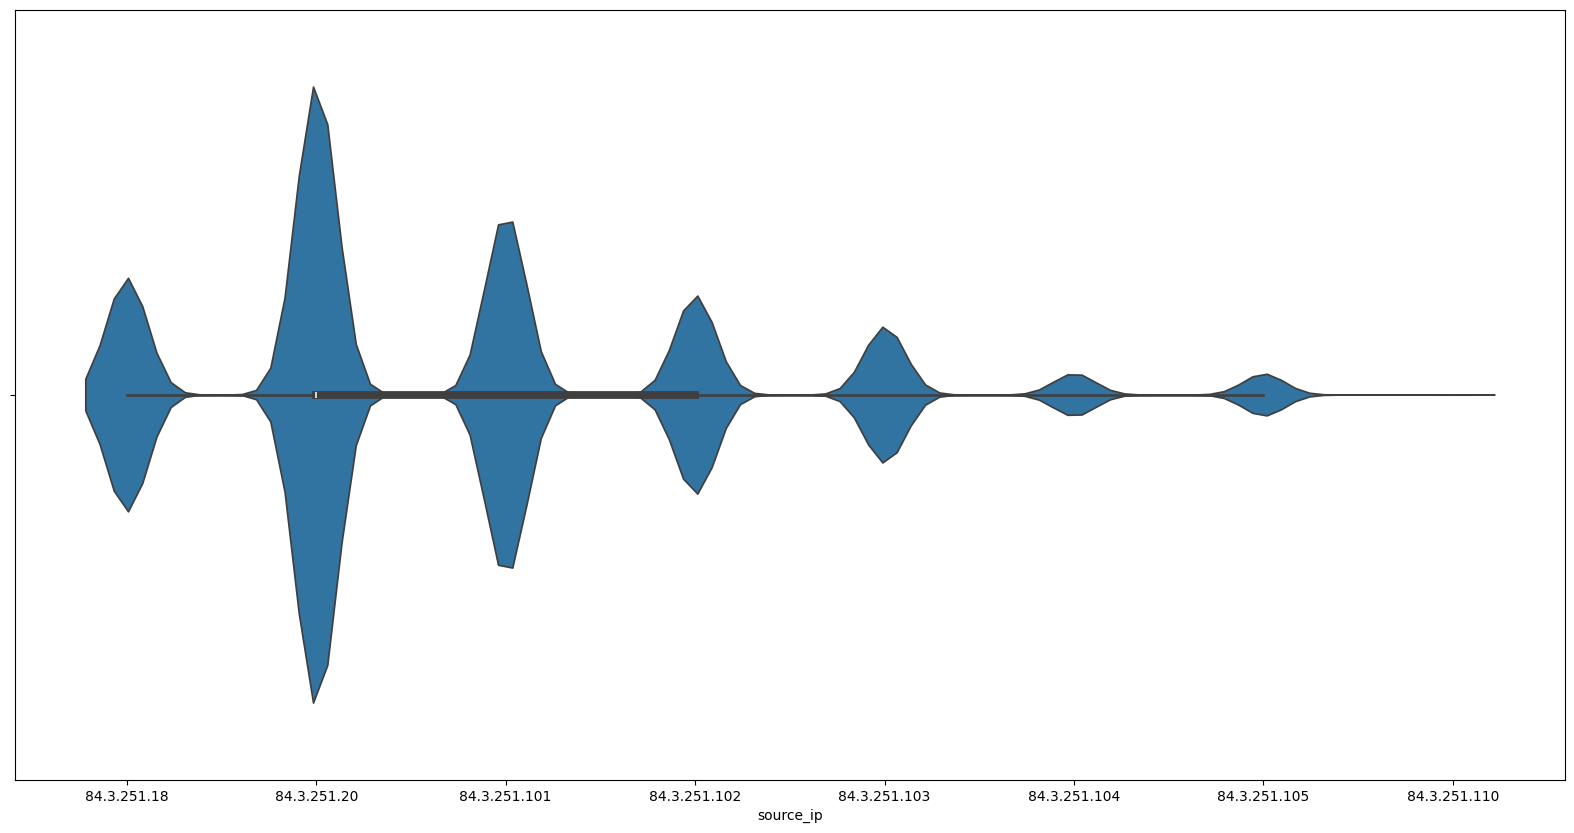

In [13]:
feature = 'source_ip'  # col

plt.figure(figsize=(20, 10))
sns.violinplot(df, x=feature)

**Interpretation:**
<br>
<br>
Wide violins, like 84.3.251.18 and 84.3.251.100, show both high variability and high density, so they are likely central assets or devices that have diverse traffic patterns. Narrow violins, like 84.3.251.104 and 84.3.251.105, tightly cluster, so they're likely static-role devices, like sensors or simply passive PLCs. There's probably  directional bias in traffic, if there's no role-specific behavior.

### Creates a count plot to display the frequency of a category

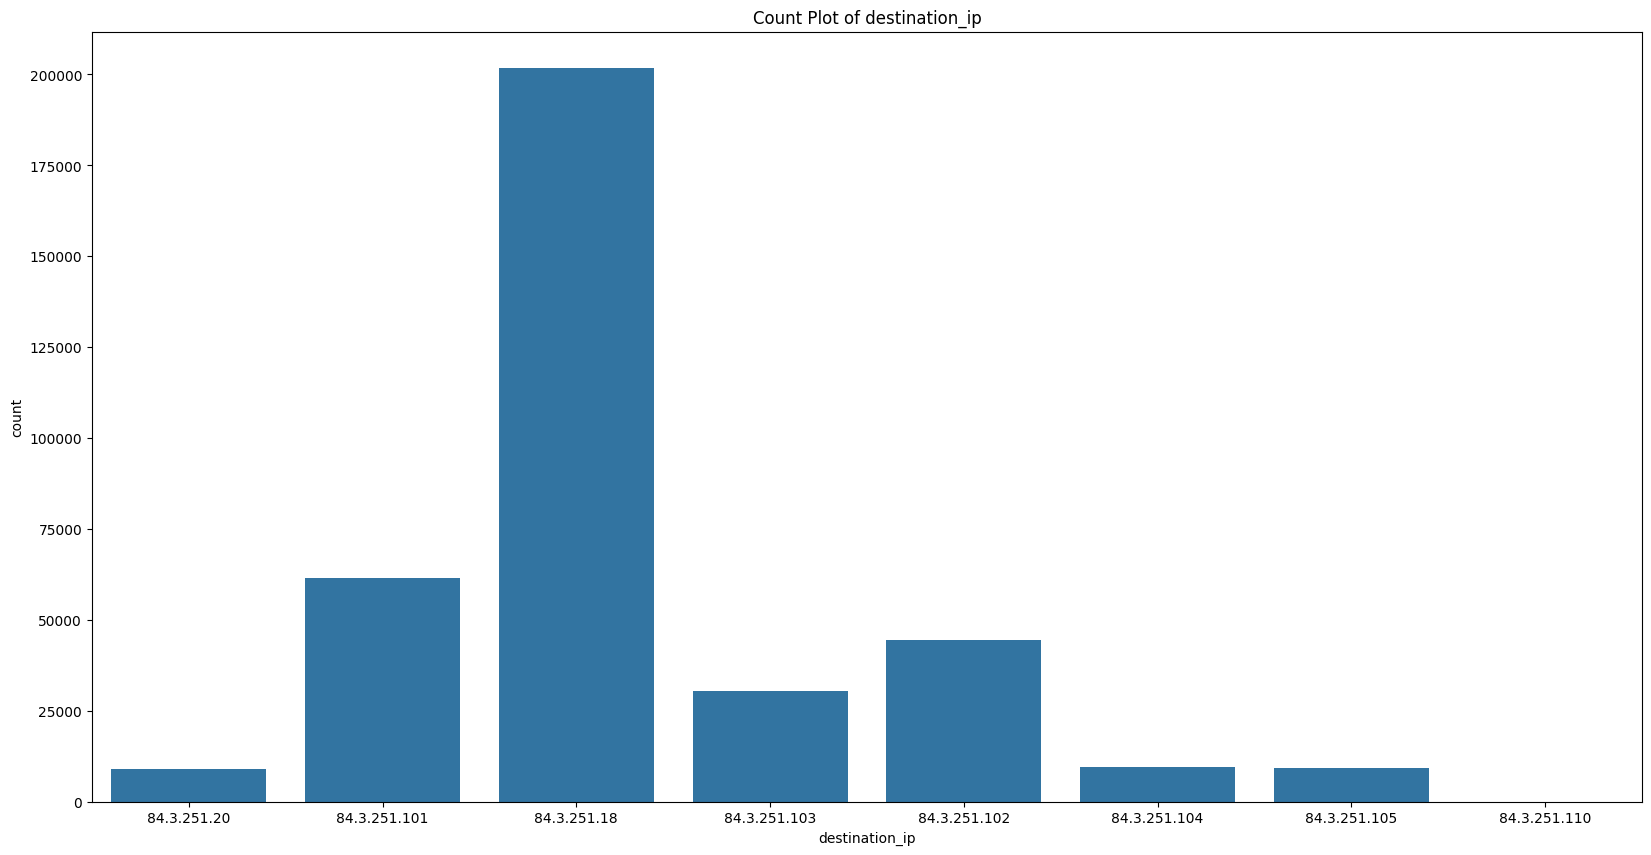

In [14]:
feature = 'destination_ip'  # col

plt.figure(figsize=(20, 10))
sns.countplot(df, x=feature)
plt.title(f"Count Plot of {feature}")
plt.show()

**Interpretation:**
<br>
<br>
The dominant IP is 84.3.251.218 with over 200,000 occurrences, which is a central asset, like an HMI, gateway or aggregation point. Secondary traffic hubs, like 84.3.251.201 and 84.3.251.203, show moderate traffic. Peripheral IPs, like 84.3.251.104, have low counts. Map these IPs to destination_asset to confirm roles, and it's a good idea to overlay attack_types to detect anomalies in high-frequency destinations.

# Step 3 -- Shows an example of each of the following two feature plots on the dataset, using hue, style and size parameters

## Two feature plots in seaborn

### Creates a scatter plot of the features provided

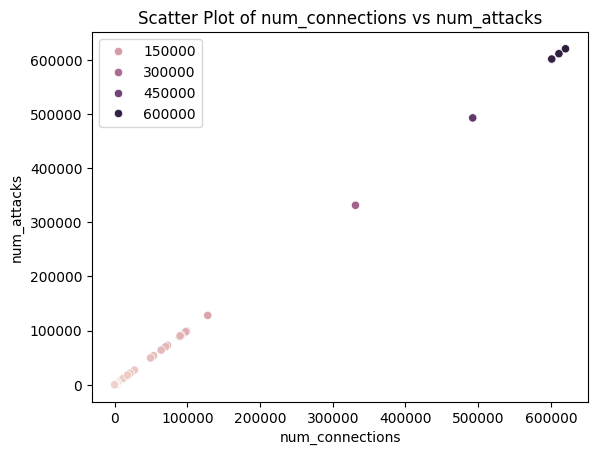

In [15]:
feature1 = 'num_connections'
feature2 = 'num_attacks'

sns.scatterplot(df, x=feature1, y=feature2, hue=feature1)
plt.title(f"Scatter Plot of {feature1} vs {feature2}")
plt.legend(loc="upper left")
plt.show()

**Interpretation:**
<br>
<br>
As num_connections increases, num_attacks rises sharply, so hyper-connected flows are more likely to be anomalous. We could use num_connections as a proxy for risk, especially above a threshold (95th percentile recommended). Overlaying source_asset or destination_asset could reveal the most vulnerable roles. Pair with categorical eatures like protocol or attack_types for supervised learning.

### Creates a swarm plot displaying the distribution of x for each group in y

In [16]:
# Data too numerous and dense for swarmplot

### Creates a strip plot displaying the distribution of x for each group in y

In [17]:
feature1 = 'num_attacks'
feature2 = 'num_connections'

plt.figure(figsize=(500, 30))
sns.stripplot(data=df, x=feature1, y=feature2, size=3, jitter=True)

<Axes: xlabel='num_attacks', ylabel='num_connections'>

**Interpretation:**
<br>
<br>
This graph shows a latent anomaly surfacing over time, because the system remains stable for most of the observed period until it experiences a sudden surge at the end. We could isolate this spike window using bucket timestamps and then compare the pre- and postbehavior. If this aligns with the expected attack_types, it could validate our detection pipeline or at least help refine our thresholds. We could also plot other metrics over time to see if they co-vary with this spike.

# Step 4 -- Perform exploratory data analysis steps on your dataset and show detailed findings

### Find the direction (either positive or negative) and the strength (strong, moderate or weak) of the correlation between features

Creates a heatmap to spot any anomaly that may be present in network traffic

<Axes: xlabel='source_ip'>

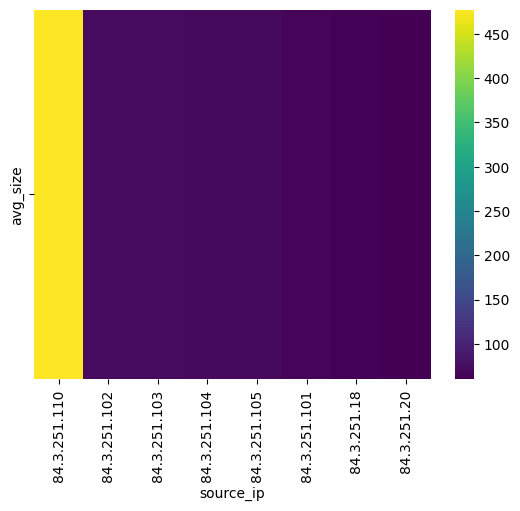

In [18]:
pivot = df.groupby('source_ip')['avg_size'].mean().nlargest(50)
sns.heatmap(pivot.to_frame().T, cmap='viridis')

**Interpretation:**
<br>
<br>
84.3.251.110 is sending significantly larger packets than any other source, while most IPs are sending minimal payloads. This IP should be flagged for deeper inspection, especially if it correlates with attack_types or unusual destination_ip patterns. Overlaying protocol could also reveal whether this spike is tied to TCP or Modbus, and mapping 84.3.251.110 to source_asset could determine its role and whether this behavior really is atypical.

Compute the correlation matrix, and then visualize with a heatmap

In [19]:
# Compute
numeric_df = df.select_dtypes(include='number')
correlation_matrix = numeric_df.corr(method='pearson')  # or 'spearman', 'kendall'
print(correlation_matrix)

                           avg_size  source_total_packets  \
avg_size                   1.000000              0.409128   
source_total_packets       0.409128              1.000000   
destination_total_packets  0.400107              0.976091   
min_size                   0.981425              0.409328   
max_size                   0.969472              0.380538   
num_connections            0.392849              0.965153   
source_port                0.019940              0.114097   
destination_port           0.333514              0.001375   
num_attacks                0.398808              0.972347   

                           destination_total_packets  min_size  max_size  \
avg_size                                    0.400107  0.981425  0.969472   
source_total_packets                        0.976091  0.409328  0.380538   
destination_total_packets                   1.000000  0.400272  0.371997   
min_size                                    0.400272  1.000000  0.918437   
max_size 

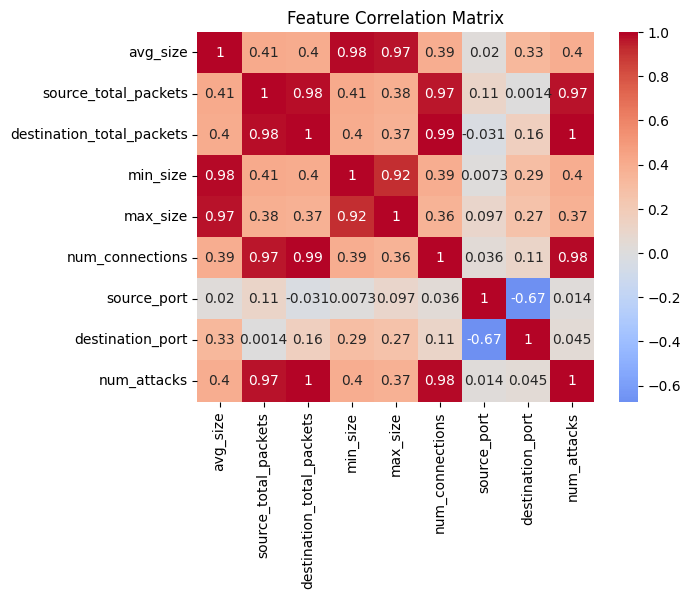

In [20]:
# Visualize
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

**Interpretation:**
<br>
<br>
num_attacks perfectly correlates with avg_size, source_total_packets and destination_total_packets. avg_size and destination_total_packets are at 0.97. source_total_packets and destination_total_packets are at 0.91. Packet volume and size thus scale together, so we should use composite traffic metrics. source_port and destination_port are instead at -0.67, possibly reflecting client-server or scan behavior, which use inverted port roles.
<br>
<br>
As previously discussed, we are dropping one of these perfectly correlated features to reduce redundancy. We are also creating ratios to capture asymmetry, but the tight link between num_attacks and the traffic metrics suggest that volume-based thresholds could be used for early detection.

# Step 5 -- Show examples of the following visualization methods on selected dataset columns

### .shape returns the dataframe's dimensions and displays as (number of instances, number of features), useful when code needs one of these dimensions

In [21]:
print(df.shape)

(366173, 21)


**Interpretation:**
<br>
<br>
Our dataset has 366,173 rows and 21 columns.

## Many-relationship visualization in pandas

### df.hist() plots a histogram for every column in the dataframe

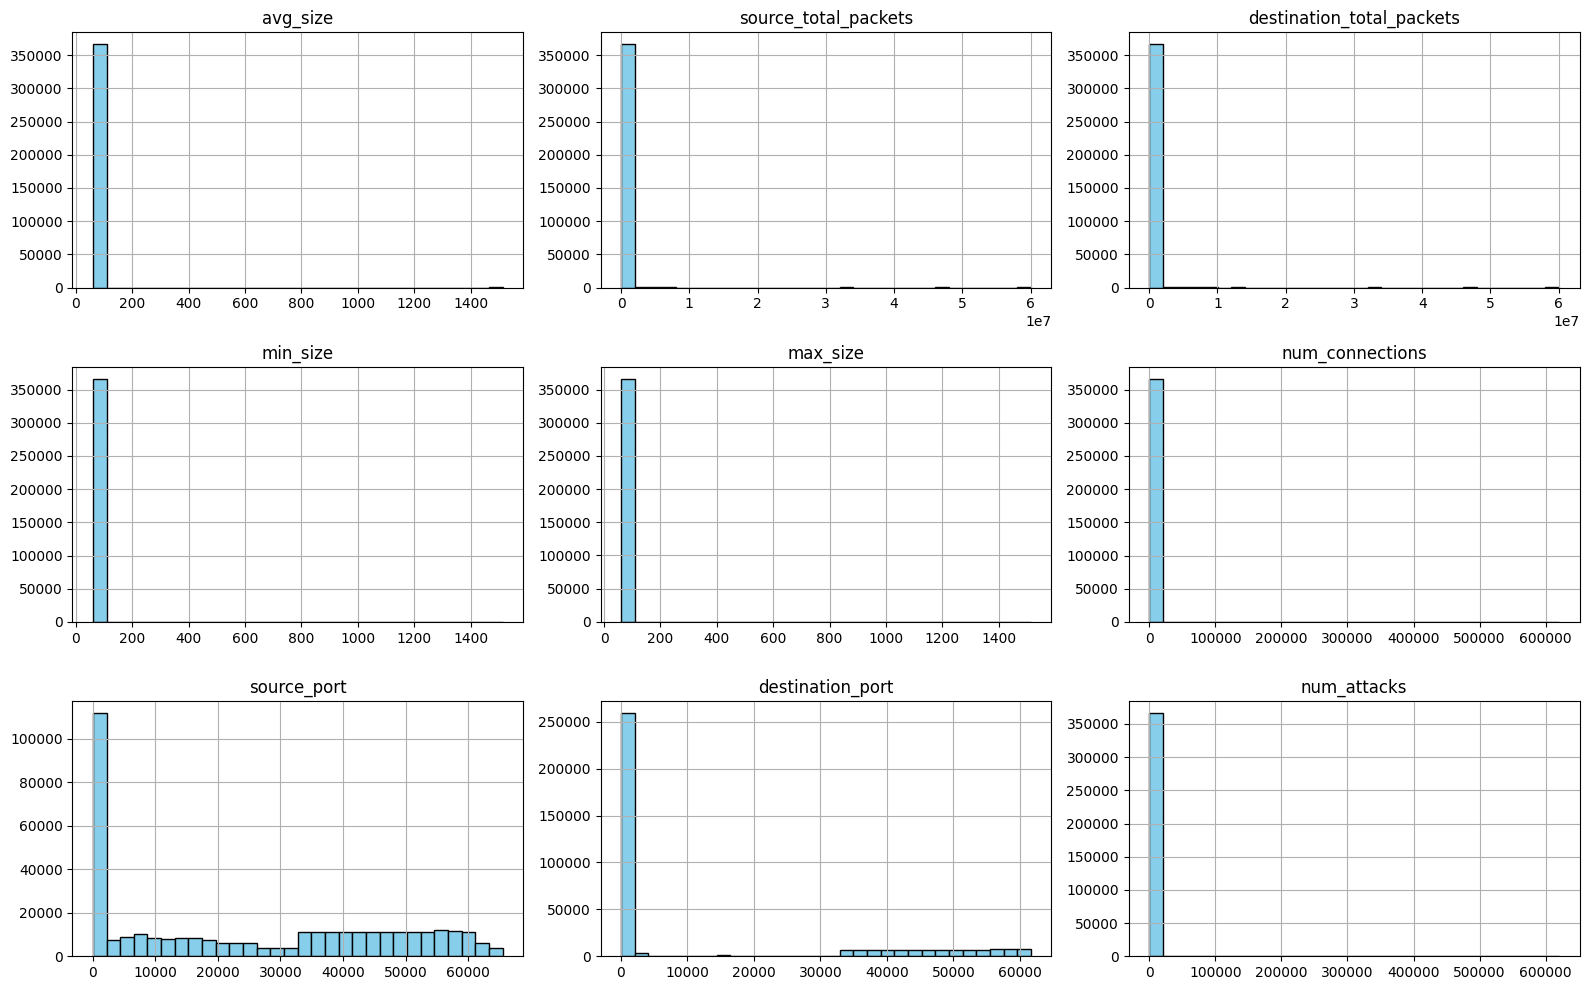

In [22]:
df.hist(figsize=(16, 10), bins=30, color='skyblue', edgecolor='black')

plt.tight_layout()
plt.show()

**Interpretation:**
<br>
<br>
avg_size, source_total_packets, destination_total_packets, num_connections and num_attacks are all highly-skewed, prime candidates for log or sqrt transformation. source_port and destination_port are possibly bimodal. min_size and max_size are tightly clustered near the origin with some outliers. Apply np.log1pp() to skewed features before clustering or regression.

### df.boxplot() plots a box plot for every column in the dataframe.

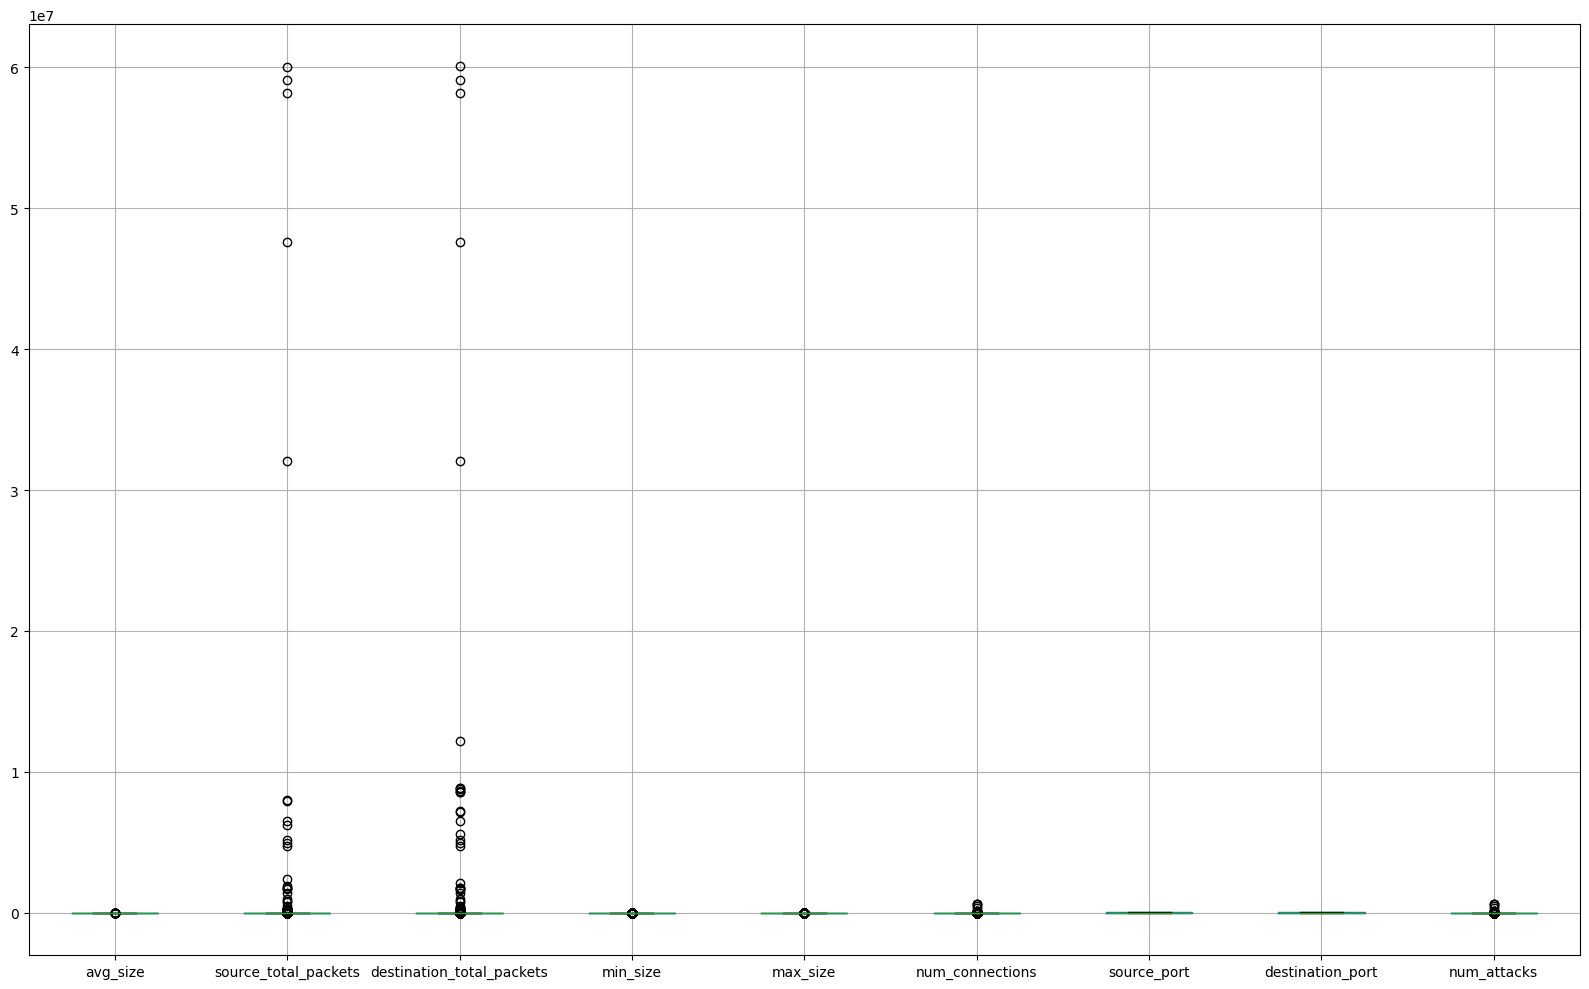

In [23]:
plt.figure(figsize=(16, 10))
df.boxplot()
plt.tight_layout()
plt.show()

**Interpretation:**
<br>
<br>
source_total_packets, destination_total_packets and num_connections show vertical spikes and are thus extreme outliers. avg_size, min_size, max_size and num_attacks are instead tightly packed near the origin with only occasional outliers, so they're compressed distributions. source_port and destination_port are more evenly spread. Scale features using standardization or robust-scaling before clustering or PCA to reduce outlier influence.

### pd.plotting.scatter_matrix(df) plots every pair of numerical features as an individual scatter plot. For more control, seaborn provides the function sns.pairplot(df).

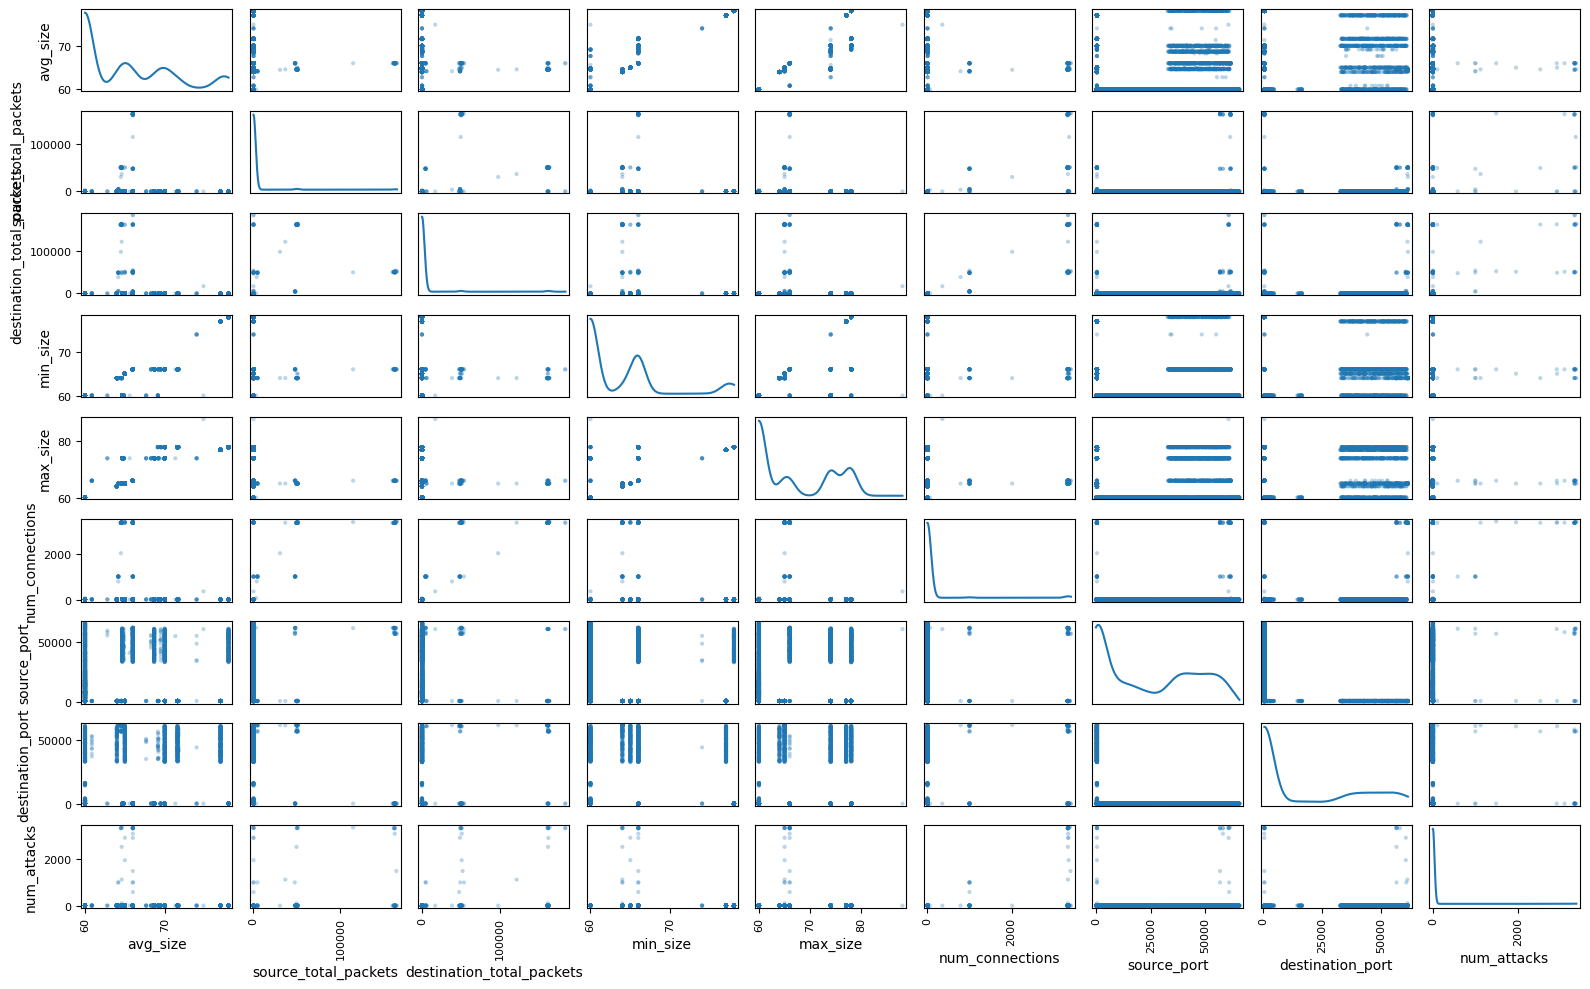

In [24]:
df_sampled = df.sample(n=5000, random_state=42)
pd.plotting.scatter_matrix(df_sampled, figsize=(16, 10), diagonal='kde', alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:**
<br>
<br>
avg_size, source_total_packets and destination_total_packets are consistent with the earlier heatmap, and should be collapsed into a composite traffic metric or elsewise used to validate attack signatures.
<br>
<br>
source_port and destination_port show discrete clustering and could be encoded as categorical or binned by protocol type. num_connections and num_attacks show long-tailed distributions with vertical outliers, so we should plan to flag high-percentile flows. Most features are indeed heavily right-skewed, confirming the need for log/sqrt transformations prior to modeling.

# Step 6 -- Try to find outliers in the dataset, show examples and how you are cleaning them

## Detect outliers

### IQR Method

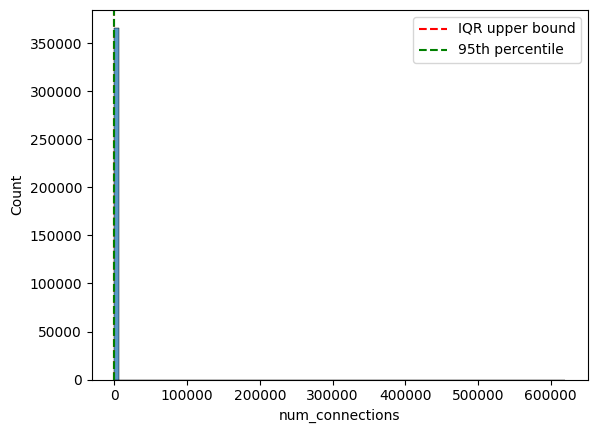

In [25]:
feature = 'num_connections'   # numerical col

Q1 = df[feature].quantile(0.25)
Q3 = df[feature].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Flag outliers
outliers = df[df[feature] > upper_bound]
percentile_95 = df[feature].quantile(0.95)
df['is_high_connection'] = (df[feature] > percentile_95).astype(int)

# Visualize overlap
sns.histplot(df[feature], bins=100)
plt.axvline(upper_bound, color='red', linestyle='--', label='IQR upper bound')
plt.axvline(percentile_95, color='green', linestyle='--', label='95th percentile')
plt.legend()

**Interpretation:**
<br>
<br>
num_connections has an extreme right-skew, because nearly all flows have a low num_connections. The IQR upper bound is slightly lower than the 95th percentile, so it's even more aggressive in flagging high-end values as outliers. Both thresholds fall within the dense cluster near the origin, however, so this reinforces how rare those massive bursts really are. An is_high_connection feature is perfect for capturing these outliers without distorting models. To see which roles and behaviors drive the tail, combine this with source_asset, protocol or attack_types.

## Deal with outliers

### Quantifies the tail in num_connections to flag the top 5% flows, creates a binary feature to preserve the anomaly signal without distorting the distribution and then normalizes it for modeling

array([[<Axes: title={'center': 'num_connections'}>,
        <Axes: title={'center': 'num_connections_log'}>],
       [<Axes: title={'center': 'num_connections_capped'}>, <Axes: >]],
      dtype=object)

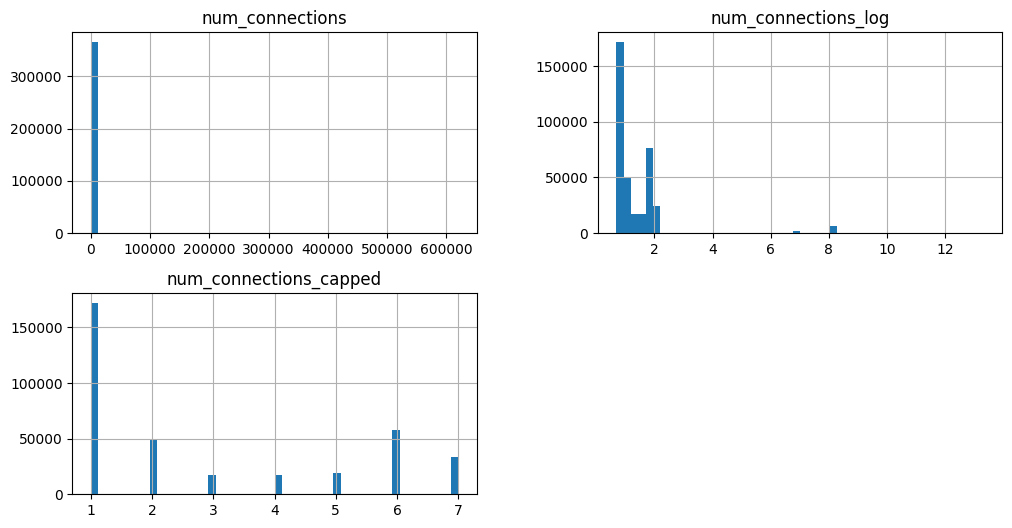

In [26]:
threshold = df['num_connections'].quantile(0.95)
df['is_high_connection'] = (df['num_connections'] > threshold).astype(int)
import numpy as np
df['num_connections_log'] = np.log1p(df['num_connections'])
df['num_connections_capped'] = df['num_connections'].clip(upper=threshold)

# Confirm distributions
df.groupby('attack_types')['is_high_connection'].mean().sort_values(ascending=False)  # validate anomaly alignment
df.groupby('source_asset')['is_high_connection'].mean().sort_values(ascending=False)  # asset profiling
df[['num_connections', 'num_connections_log', 'num_connections_capped']].hist(bins=50, figsize=(12, 6))

**Interpretation:**
<br>
<br>
The raw graph of num_connections is dominated by low values and has a massive right tail, and the log-transformed graph titled num_connections_log is much more symmetric and compact -- more ideal for clustering, regression and PCA. This better preserves rank and relative scale, while still taming the outliers. The capped graph titled num_connections_capped is discretized into a few bins, specifically 1-7, simplifying modeling and reducing outlier influence. The capped graph is better for tree-based models and categorical analysis.